# Appendix — coherent vs directly predicted GGI

Compares the internally coherent GGI (derived as predicted-female / predicted-male) against the
separately modelled GGI, across five appendix analyses:

| | |
| --- | --- |
| **A** | Scatter, direct vs coherent raw, by continent, for 2015 / 2020 / 2025 |
| **B** | Distribution of the difference (coherent − direct) |
| **C** | Country trajectories under both definitions, for a rule-selected country set |
| **D** | Regional robustness under three definitions, with a rank table |
| **E** | Paper-ready appendix paragraph |

**All data is prepared by `src/14_coherent_ggi_comparison.py`** and read from `outputs/tables/`.
This notebook contains plotting only — no analysis is computed here, so every number in a figure is
traceable to a saved CSV.

Two things carried over from the main analysis: the sample excludes Yemen and the sanctioned
countries (D21), and the trend window ends 2025, the last complete year (D18).

In [1]:
import _bootstrap  # noqa: F401  — puts src/ on sys.path
import re
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import params

warnings.filterwarnings('ignore')

STYLE = params.STYLE
PALETTE = STYLE['colors']
INK, MUTED, GRID = '#222222', '#666666', '#d9d9d9'
FIGDIR = params.fig_dir('coherent_ggi') / 'ggi_comparison'
FIGDIR.mkdir(parents=True, exist_ok=True)


def latest(stem):
    """
    most recent date-stamped build from src/14_coherent_ggi_comparison.py

    The suffix must be exactly a date, otherwise 'scatter' would also match 'scatter_stats' and
    'regional' would match 'regional_table'.
    """
    matches = sorted(f for f in params.table_dir('coherent_ggi').glob(f'ggi_comparison_{stem}_*.csv')
                     if re.fullmatch(rf'ggi_comparison_{stem}_\d{{8}}\.csv', f.name))
    if not matches:
        raise FileNotFoundError(f'no ggi_comparison_{stem}_<date>.csv — run src/14_coherent_ggi_comparison.py')
    return pd.read_csv(matches[-1])


def latest_gt(stem):
    """
    the survey-validation tables, which stage 03 (model performance) produces

    They score predicted against observed, so they belong to the model-performance step even
    though the GGI comparison also reads them — see doc/workflow.md.
    """
    matches = sorted(f for f in params.table_dir('model_performance').glob(
        f'model_performance_{stem}_*.csv')
        if re.fullmatch(rf'model_performance_{stem}_\d{{8}}\.csv', f.name))
    if not matches:
        raise FileNotFoundError(f'no model_performance_{stem}_<date>.csv — '
                                'run src/model_performance.py')
    return pd.read_csv(matches[-1])


scatter        = latest('scatter')
scatter_stats  = latest('scatter_stats')
differences    = latest('differences')
diff_summary   = latest('difference_summary')
selection      = latest('trend_selection')
trends         = latest('trends')
regional       = latest('regional')
regional_table = latest('regional_table')
stability      = latest('rank_stability')
gt             = latest_gt('groundtruth')
gt_stats       = latest_gt('groundtruth_stats')
gt_levels      = latest_gt('groundtruth_levels')
gt_level_stats = latest_gt('groundtruth_level_stats')
unseen         = latest_gt('unseen_surveys')

CONTINENTS = sorted(scatter['continent'].dropna().unique())
CONTINENT_COLOUR = dict(zip(CONTINENTS, PALETTE))
DEF_LABEL = {'coherent_parity': 'Coherent (parity-capped)',
             'coherent_raw': 'Coherent (raw)',
             'direct': 'Directly predicted'}

# Section F distinguishes two things only, so it takes the first two hues of the project's
# categorical order (params.plot_color_order, rebuilt for colour-vision accessibility in D23) and
# backs them with marker shape, so the split survives a greyscale print.
SAMPLE_COLOUR = {'held_out': PALETTE[1], 'in_training': PALETTE[0], 'all': PALETTE[0],
                 'all_excl_zero': PALETTE[2]}
SAMPLE_MARKER = {'held_out': '^', 'in_training': 'o', 'all': 'o', 'all_excl_zero': 's'}
SAMPLE_LABEL = {'held_out': 'Held out (not fitted)', 'in_training': 'In the fitted panel',
                'all': 'All surveys', 'all_excl_zero': 'Excluding zero-floor rows'}

# Rows where the predicted female level sits on the zero floor: the coherent GGI is 0/male = 0 by
# construction there (D19), so it reports the clip rather than a gap. params.delete_coherent_zero_ctrl
# decides whether the filtered sample is reported alongside; the mark below is always drawn.
ZERO_CTRL = params.delete_coherent_zero_ctrl
ZERO_RING = '#c0392b'

print(f"{scatter['gid_0'].nunique()} countries | continents: {', '.join(CONTINENTS)}")


def tidy(ax, title=None, xlabel=None, ylabel=None):
    """the project's axis treatment: recessive frame, muted labels, y-grid only"""
    if title:
        ax.set_title(title, fontsize=STYLE['label_fs'], color=INK, fontweight='bold', loc='left')
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=STYLE['tick_fs'], color=MUTED)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=STYLE['tick_fs'], color=MUTED)
    ax.tick_params(labelsize=STYLE['tick_fs'] - 1, colors=MUTED)
    ax.grid(axis='y', color=GRID, linewidth=0.5, alpha=0.6)
    ax.set_axisbelow(True)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    for s in ['left', 'bottom']:
        ax.spines[s].set_color(GRID)
    return ax

210 countries | continents: Africa, Asia, Europe, North America, Oceania, South America


## A. Direct vs coherent, by continent

x is the directly predicted GGI, y the **raw** (uncapped) coherent GGI. Axes deliberately extend
past 1 so values above parity are visible rather than truncated — that is where the two definitions
diverge most. The dashed line is y = x: points above it are countries where the coherent measure
reports a *smaller* gender gap than the direct model does.

,indicator,year,n,pearson_r,spearman_r,n_above_1_coherent_raw,max_coherent_raw,mean_abs_diff
0,internet,2015,210,0.9217,0.8454,29,1.3948,0.0801
1,internet,2020,210,0.9259,0.8727,39,1.1008,0.0461
2,internet,2025,210,0.9297,0.8576,26,1.0698,0.0327
3,mobile,2015,210,0.9841,0.8970,52,1.0743,0.0176
4,mobile,2020,210,0.9765,0.8656,88,1.1182,0.0195
5,mobile,2025,210,0.9605,0.8153,87,1.1240,0.0193


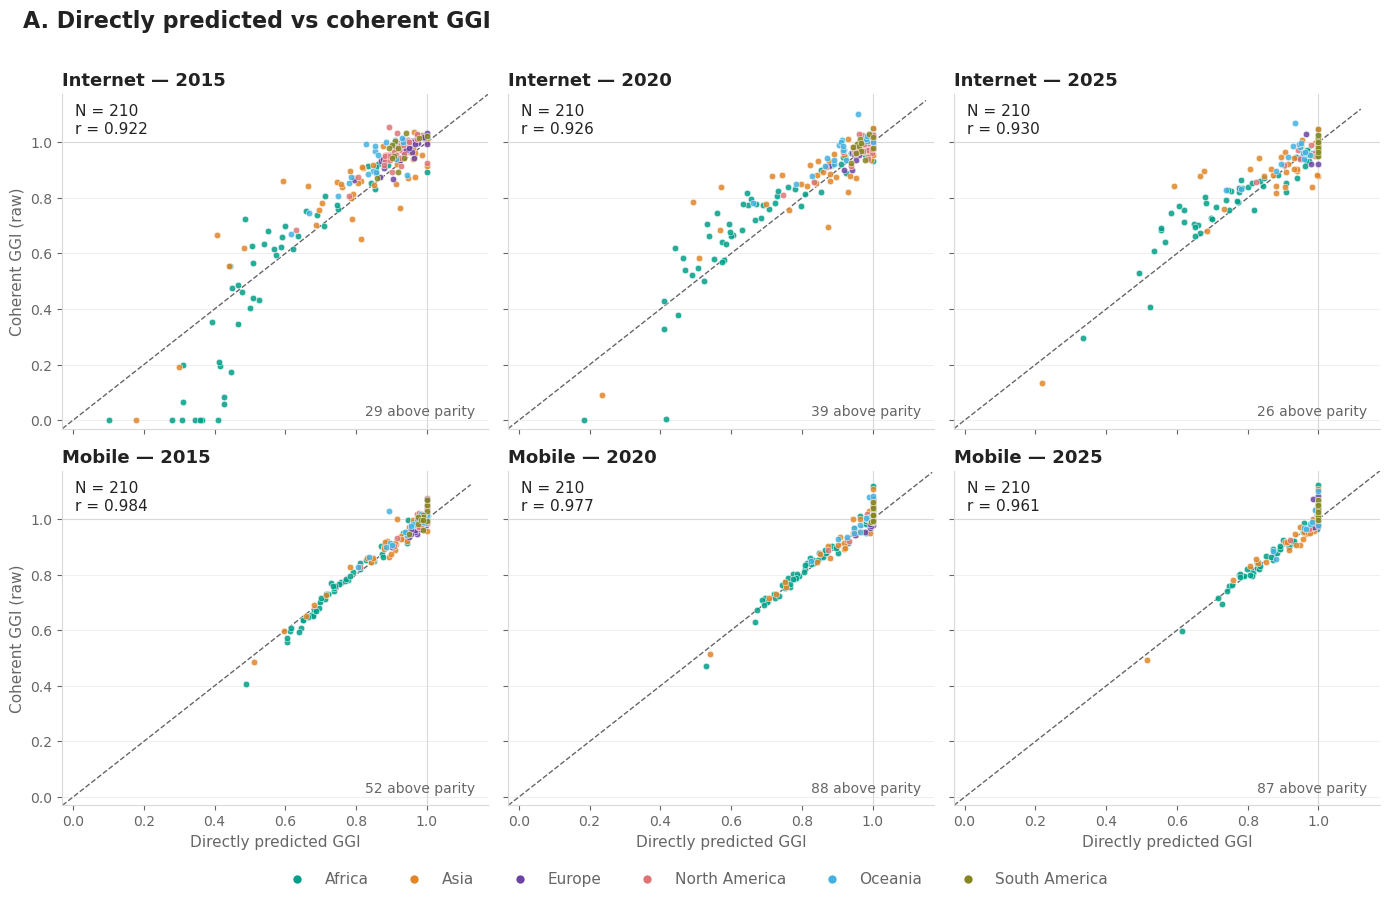

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True)

for row, indicator in enumerate(params.COHERENT_GGI['indicators']):
    for col, year in enumerate(params.COHERENT_GGI['focus_years']):
        ax = axes[row, col]
        block = scatter[(scatter['indicator'] == indicator) & (scatter['year'] == year)]
        st = scatter_stats[(scatter_stats['indicator'] == indicator)
                           & (scatter_stats['year'] == year)].iloc[0]

        lim = (-0.03, max(1.05, block[['direct', 'coherent_raw']].max().max() + 0.05))
        ax.plot(lim, lim, ls='--', color=MUTED, linewidth=1, zorder=1)
        ax.axhline(1.0, color=GRID, linewidth=0.8, zorder=1)
        ax.axvline(1.0, color=GRID, linewidth=0.8, zorder=1)

        for continent in CONTINENTS:
            pts = block[block['continent'] == continent]
            ax.scatter(pts['direct'], pts['coherent_raw'], s=22, alpha=0.85,
                       color=CONTINENT_COLOUR[continent], edgecolor='white',
                       linewidth=0.4, zorder=3)

        ax.text(0.03, 0.97, f"N = {int(st['n'])}\nr = {st['pearson_r']:.3f}",
                transform=ax.transAxes, va='top', ha='left',
                fontsize=STYLE['tick_fs'], color=INK)
        ax.text(0.97, 0.03, f"{int(st['n_above_1_coherent_raw'])} above parity",
                transform=ax.transAxes, va='bottom', ha='right',
                fontsize=STYLE['tick_fs'] - 1, color=MUTED)

        tidy(ax, title=f'{indicator.capitalize()} — {year}')
        ax.set_xlim(lim); ax.set_ylim(lim)
        if row == 1:
            ax.set_xlabel('Directly predicted GGI', fontsize=STYLE['tick_fs'], color=MUTED)
        if col == 0:
            ax.set_ylabel('Coherent GGI (raw)', fontsize=STYLE['tick_fs'], color=MUTED)

# one figure-level legend: inside a panel it collided with the 'above parity' annotation
handles = [plt.Line2D([], [], marker='o', linestyle='None', markersize=7,
                      markerfacecolor=CONTINENT_COLOUR[c], markeredgecolor='white', label=c)
           for c in CONTINENTS]
fig.legend(handles=handles, loc='lower center', ncol=len(CONTINENTS), frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('A. Directly predicted vs coherent GGI', fontsize=STYLE['title_fs'],
             color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig(FIGDIR / 'A_scatter_direct_vs_coherent.png', dpi=STYLE['dpi'], bbox_inches='tight')
scatter_stats.round(4)

## B. Distribution of the difference

`coherent (parity-capped) − direct`, pooled over 2015–2025. The left panel is the full distribution;
the right splits by continent. The dashed line marks zero — perfect agreement between definitions.

,indicator,continent,n,mean,median,sd,q05,q95,pct_positive
0,internet,Africa,572,0.0156,0.0332,0.1107,-0.2425,0.1541,68.1818
1,internet,Asia,506,0.0218,0.0097,0.0849,-0.1159,0.1782,54.1502
2,internet,Europe,495,0.0064,0.0000,0.0223,-0.0270,0.0495,41.2121
3,internet,North America,385,0.0147,0.0102,0.0297,-0.0284,0.0639,58.4416
4,internet,Oceania,220,0.0526,0.0507,0.0467,-0.0081,0.1192,85.9091
5,internet,South America,132,0.0094,0.0008,0.0315,-0.0357,0.0684,50.7576
6,mobile,Africa,572,0.0033,0.0040,0.0177,-0.0306,0.0272,59.0909
7,mobile,Asia,506,0.0017,0.0000,0.0181,-0.0279,0.0308,37.9447
8,mobile,Europe,495,-0.0023,0.0000,0.0067,-0.0183,0.0000,4.6465
9,mobile,North America,385,0.0013,0.0000,0.0057,-0.0051,0.0152,17.1429


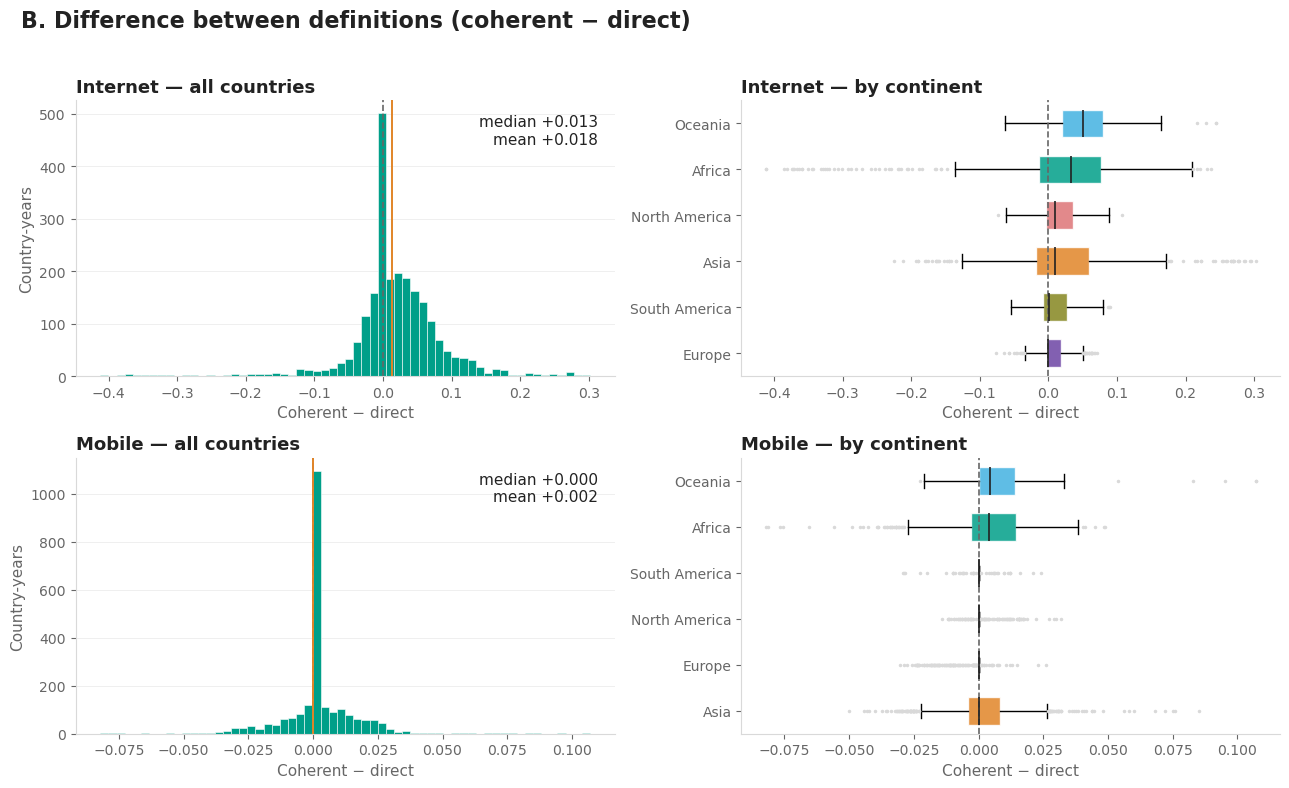

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for row, indicator in enumerate(params.COHERENT_GGI['indicators']):
    block = differences[differences['indicator'] == indicator]

    ax = axes[row, 0]
    ax.hist(block['diff_parity'].dropna(), bins=60, color=PALETTE[0],
            edgecolor='white', linewidth=0.4)
    ax.axvline(0, ls='--', color=MUTED, linewidth=1.2)
    med = block['diff_parity'].median()
    ax.axvline(med, ls='-', color=PALETTE[1], linewidth=1.4)
    ax.text(0.97, 0.95, f'median {med:+.3f}\nmean {block["diff_parity"].mean():+.3f}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=STYLE['tick_fs'], color=INK)
    tidy(ax, title=f'{indicator.capitalize()} — all countries',
         xlabel='Coherent − direct', ylabel='Country-years')

    ax = axes[row, 1]
    order = (block.groupby('continent')['diff_parity'].median().sort_values().index.tolist())
    data = [block.loc[block['continent'] == c, 'diff_parity'].dropna() for c in order]
    bp = ax.boxplot(data, vert=False, patch_artist=True, widths=0.6,
                    medianprops=dict(color=INK, linewidth=1.2),
                    flierprops=dict(marker='.', markersize=3, markerfacecolor=GRID,
                                    markeredgecolor=GRID))
    for patch, continent in zip(bp['boxes'], order):
        patch.set_facecolor(CONTINENT_COLOUR[continent])
        patch.set_alpha(0.85)
        patch.set_edgecolor('white')
    ax.axvline(0, ls='--', color=MUTED, linewidth=1.2)
    ax.set_yticks(range(1, len(order) + 1))
    ax.set_yticklabels(order)
    tidy(ax, title=f'{indicator.capitalize()} — by continent', xlabel='Coherent − direct')
    ax.grid(axis='y', visible=False)

fig.suptitle('B. Difference between definitions (coherent − direct)',
             fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(FIGDIR / 'B_difference_distributions.png', dpi=STYLE['dpi'], bbox_inches='tight')
diff_summary.round(4)

## C. Country trajectories under both definitions

Countries are chosen by a rule fixed in `src/14_coherent_ggi_comparison.py` **before** any figure was
drawn:

> For each indicator, compute each country's mean signed discrepancy (coherent parity-capped −
> direct) over 2015–2025. Rank all countries in the common sample. Take the three largest positive,
> the three largest negative, and the three closest to zero. Ties break alphabetically on ISO3.

No country was added or removed after inspecting results.

In [4]:
selection.sort_values(['indicator', 'group', 'mean_discrepancy'],
                      ascending=[True, True, False]).round(4)

,gid_0,country,continent,indicator,group,mean_discrepancy
5,AFG,Afghanistan,Asia,internet,largest_negative,-0.1591
4,IRQ,Iraq,Asia,internet,largest_negative,-0.1612
3,SOM,Somalia,Africa,internet,largest_negative,-0.2908
0,TJK,Tajikistan,Asia,internet,largest_positive,0.2787
1,UZB,Uzbekistan,Asia,internet,largest_positive,0.2531
2,GNQ,Equatorial Guinea,Africa,internet,largest_positive,0.1742
8,THA,Thailand,Asia,internet,smallest,0.0002
7,GEO,Georgia,Asia,internet,smallest,0.0001
6,SYC,Seychelles,Africa,internet,smallest,0.0000
14,TUN,Tunisia,Africa,mobile,largest_negative,-0.0306


  C_country_trends_internet.png


  C_country_trends_mobile.png


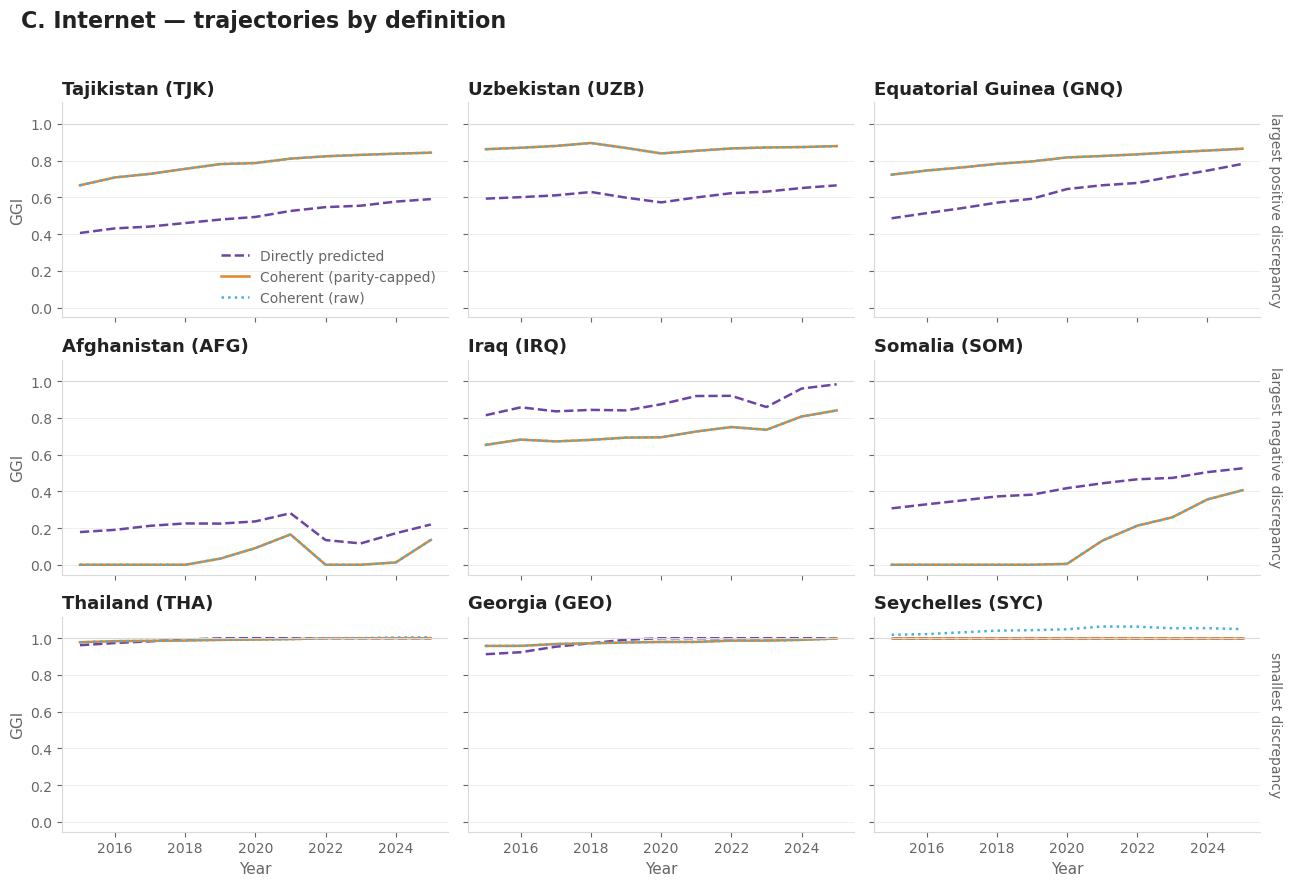

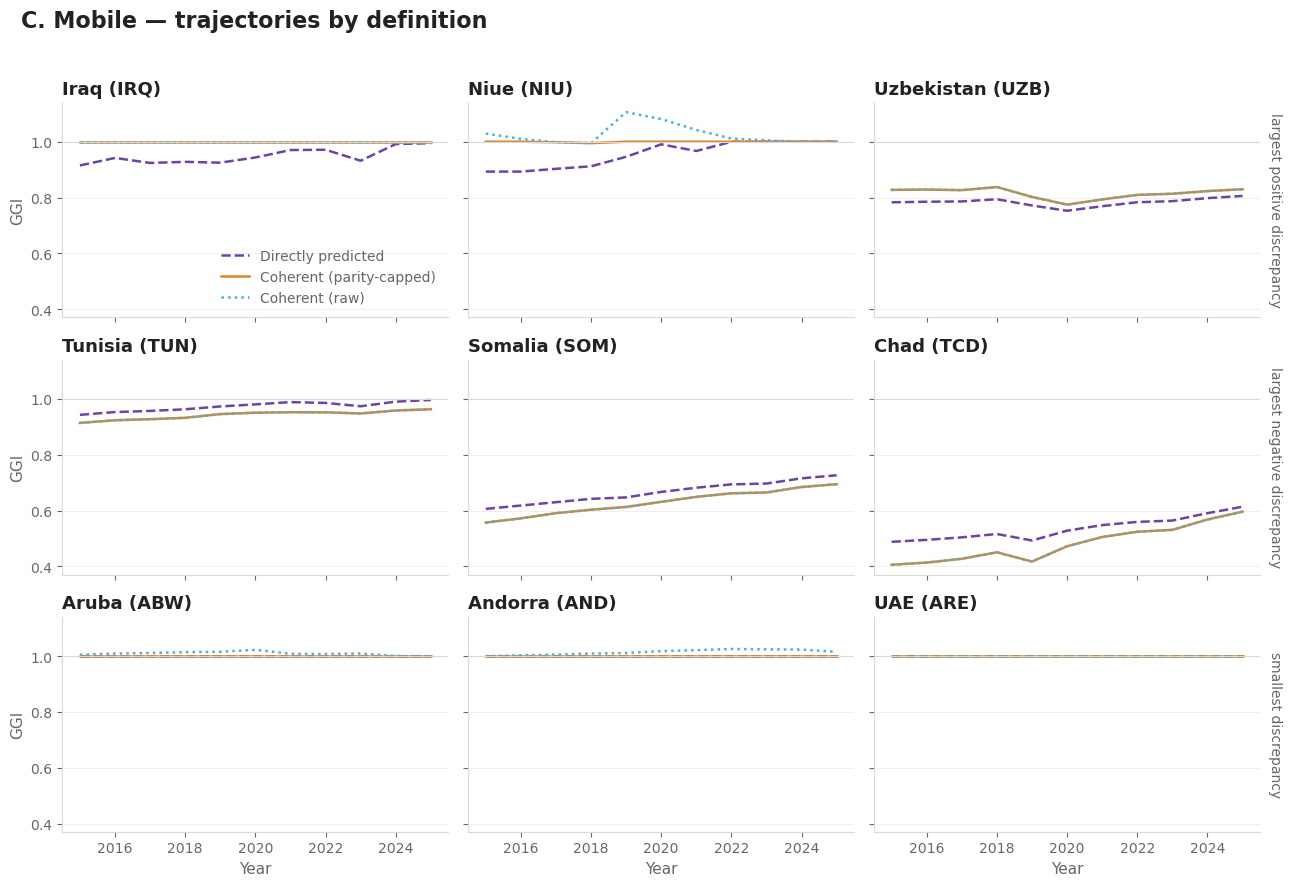

In [5]:
GROUP_TITLE = {'largest_positive': 'largest positive discrepancy',
               'largest_negative': 'largest negative discrepancy',
               'smallest': 'smallest discrepancy'}
LINE_STYLE = {'direct': dict(ls='--', color=PALETTE[2]),
              'coherent_parity': dict(ls='-', color=PALETTE[1]),
              'coherent_raw': dict(ls=':', color=PALETTE[4])}

for indicator in params.COHERENT_GGI['indicators']:
    picks = selection[selection['indicator'] == indicator]
    groups = ['largest_positive', 'largest_negative', 'smallest']
    n_per = picks.groupby('group').size().max()

    fig, axes = plt.subplots(len(groups), n_per, figsize=(13, 9), sharex=True, sharey=True)
    for r, group in enumerate(groups):
        members = picks[picks['group'] == group].sort_values('mean_discrepancy', ascending=False)
        for c in range(n_per):
            ax = axes[r, c]
            if c >= len(members):
                ax.axis('off'); continue
            iso = members.iloc[c]['gid_0']
            block = trends[(trends['indicator'] == indicator) & (trends['gid_0'] == iso)]
            for definition, style in LINE_STYLE.items():
                sub = block[block['definition'] == definition].sort_values('year')
                ax.plot(sub['year'], sub['value'], linewidth=1.8, **style,
                        label=DEF_LABEL[definition] if (r == 0 and c == 0) else None)
            ax.axhline(1.0, color=GRID, linewidth=0.8)
            name = block['country'].iloc[0] if len(block) else iso
            tidy(ax, title=f'{name} ({iso})')
            if c == 0:
                ax.set_ylabel('GGI', fontsize=STYLE['tick_fs'], color=MUTED)
            if c == n_per - 1:
                # row tag on the right margin: the y axis is a GGI, not a discrepancy
                ax.text(1.02, 0.5, GROUP_TITLE[group], transform=ax.transAxes,
                        rotation=270, va='center', ha='left',
                        fontsize=STYLE['tick_fs'] - 1, color=MUTED)
            if r == len(groups) - 1:
                ax.set_xlabel('Year', fontsize=STYLE['tick_fs'], color=MUTED)

    axes[0, 0].legend(frameon=False, fontsize=STYLE['tick_fs'] - 1,
                      loc='lower right', labelcolor=MUTED)
    fig.suptitle(f'C. {indicator.capitalize()} — trajectories by definition',
                 fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    fig.savefig(FIGDIR / f'C_country_trends_{indicator}.png',
                dpi=STYLE['dpi'], bbox_inches='tight')
    print(f'  C_country_trends_{indicator}.png')

## D. Regional robustness

The main regional trend figure, rebuilt under each of the three definitions on an **identical
country sample** (countries complete under all definitions and both indicators) and an identical
aggregation rule (unweighted country mean within World Bank region). The only thing that varies
between columns is the definition.

  D_regional_definitions_internet.png


  D_regional_definitions_mobile.png


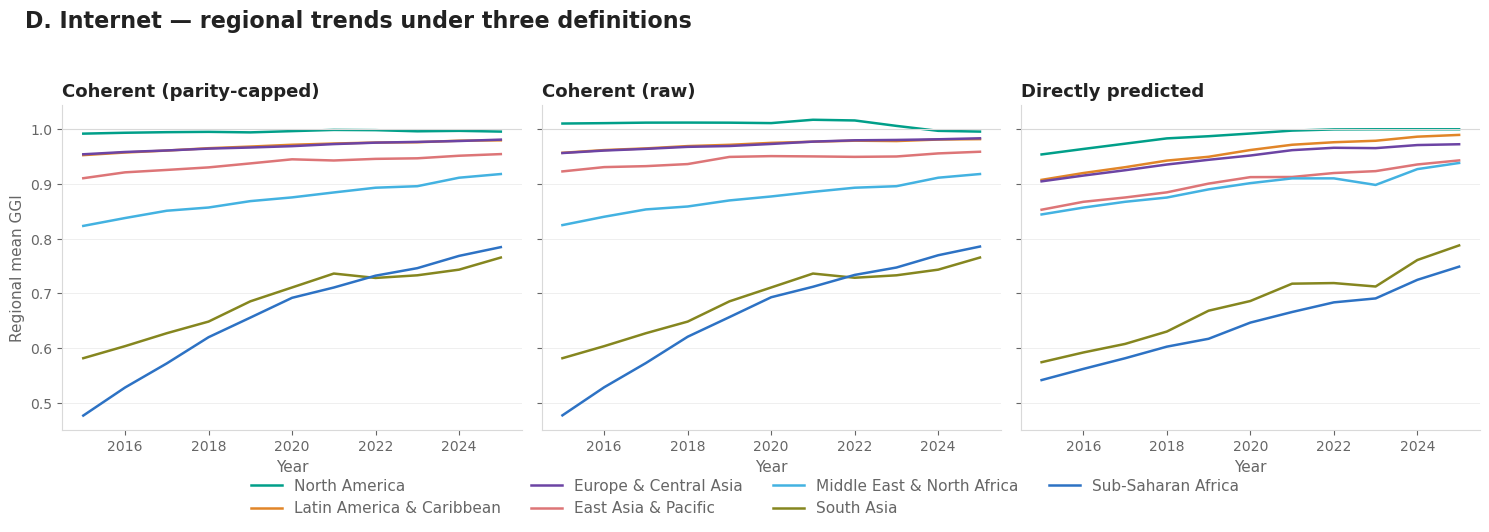

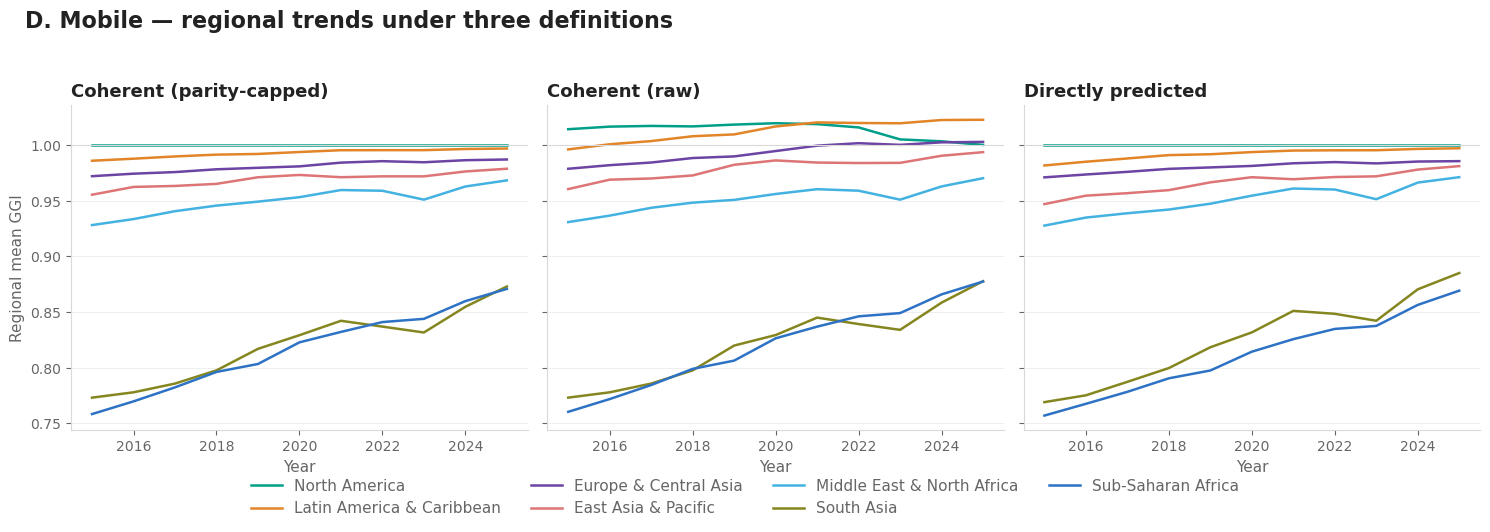

In [6]:
for indicator in params.COHERENT_GGI['indicators']:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
    block = regional[regional['indicator'] == indicator]
    order = (block[(block['definition'] == 'direct') & (block['year'] == 2025)]
             .sort_values('value', ascending=False)['region'].tolist())

    for ax, definition in zip(axes, ['coherent_parity', 'coherent_raw', 'direct']):
        sub = block[block['definition'] == definition]
        for i, region in enumerate(order):
            line = sub[sub['region'] == region].sort_values('year')
            ax.plot(line['year'], line['value'], linewidth=1.8,
                    color=PALETTE[i % len(PALETTE)])
        ax.axhline(1.0, color=GRID, linewidth=0.8)
        tidy(ax, title=DEF_LABEL[definition], xlabel='Year')
    axes[0].set_ylabel('Regional mean GGI', fontsize=STYLE['tick_fs'], color=MUTED)

    handles = [plt.Line2D([], [], color=PALETTE[i % len(PALETTE)], linewidth=1.8, label=r)
               for i, r in enumerate(order)]
    fig.legend(handles=handles, loc='lower center', ncol=4, frameon=False,
               fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.06))

    fig.suptitle(f'D. {indicator.capitalize()} — regional trends under three definitions',
                 fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
    fig.tight_layout(rect=[0, 0.02, 1, 0.94])
    fig.savefig(FIGDIR / f'D_regional_definitions_{indicator}.png',
                dpi=STYLE['dpi'], bbox_inches='tight')
    print(f'  D_regional_definitions_{indicator}.png')

In [7]:
# regional values, change and rank under each definition
regional_table.round(4)

,indicator,definition,region,value_2015,value_2025,abs_change,rank_2025,rank_change
0,internet,coherent_parity,North America,0.9920,0.9957,0.0037,1,7
1,internet,coherent_parity,Europe & Central Asia,0.9543,0.9811,0.0268,2,6
2,internet,coherent_parity,Latin America & Caribbean,0.9527,0.9798,0.0270,3,5
3,internet,coherent_parity,East Asia & Pacific,0.9106,0.9546,0.0441,4,4
4,internet,coherent_parity,Middle East & North Africa,0.8235,0.9182,0.0948,5,3
5,internet,coherent_parity,Sub-Saharan Africa,0.4770,0.7847,0.3077,6,1
6,internet,coherent_parity,South Asia,0.5818,0.7657,0.1839,7,2
7,internet,coherent_raw,North America,1.0105,0.9957,-0.0147,1,7
8,internet,coherent_raw,Europe & Central Asia,0.9566,0.9835,0.0269,2,5
9,internet,coherent_raw,Latin America & Caribbean,0.9570,0.9820,0.0250,3,6


In [8]:
# where the definition changes the regional ordering
stability.round(4)

,indicator,region,rank_coherent_parity,rank_coherent_raw,rank_direct,value_coherent_parity,value_coherent_raw,value_direct,rank_changes,max_rank_shift,max_value_spread
0,internet,North America,1,1,1,0.9957,0.9957,1.0000,False,0,0.0043
1,internet,Latin America & Caribbean,3,3,2,0.9798,0.9820,0.9897,True,1,0.0099
2,internet,Europe & Central Asia,2,2,3,0.9811,0.9835,0.9726,True,1,0.0109
3,internet,East Asia & Pacific,4,4,4,0.9546,0.9589,0.9431,False,0,0.0158
4,internet,Middle East & North Africa,5,5,5,0.9182,0.9182,0.9384,False,0,0.0202
5,internet,South Asia,7,7,6,0.7657,0.7657,0.7878,True,1,0.0221
6,internet,Sub-Saharan Africa,6,6,7,0.7847,0.7858,0.7490,True,1,0.0367
7,mobile,North America,1,3,1,1.0000,1.0003,1.0000,True,2,0.0003
8,mobile,Latin America & Caribbean,2,1,2,0.9970,1.0229,0.9973,True,1,0.0259
9,mobile,Europe & Central Asia,3,2,3,0.9872,1.0030,0.9857,True,1,0.0173


## E. Appendix text

Generated from the tables above so the prose cannot drift from the numbers. It describes the two
definitions as alternative constructions rather than treating either as observed: both are model
output, and no survey measurement of the gender gap enters at this stage.

In [9]:
def appendix_paragraph():
    """compose the appendix text from the computed statistics"""
    lines = []

    r_lo = scatter_stats['pearson_r'].min()
    r_hi = scatter_stats['pearson_r'].max()
    lines.append(
        'We compare two constructions of the national digital gender gap. The first is the gender '
        'gap index predicted directly by its own model; the second is the internally coherent '
        'index, formed as the ratio of the separately predicted female and male adoption levels. '
        'Neither is an observed quantity: both are model output for country-months in which no '
        'survey was fielded, and the comparison below concerns their consistency with one another '
        'rather than their accuracy against a measured benchmark.')

    lines.append(
        f'Across 2015-2025 the two move together closely (Pearson r between {r_lo:.2f} and '
        f'{r_hi:.2f} in the snapshot years), but they are not interchangeable.')

    for ind in params.COHERENT_GGI['indicators']:
        st = scatter_stats[scatter_stats['indicator'] == ind]
        first, last = st.iloc[0], st.iloc[-1]
        d = differences[differences['indicator'] == ind]['diff_parity']
        # the direction of travel differs by indicator, so do not hardcode "falls"
        delta = last['mean_abs_diff'] - first['mean_abs_diff']
        verb = ('falls from' if delta < -0.001 else
                'rises from' if delta > 0.001 else 'is essentially unchanged at')
        span = (f'{first["mean_abs_diff"]:.3f} in {int(first["year"])} to '
                f'{last["mean_abs_diff"]:.3f} in {int(last["year"])}'
                if abs(delta) > 0.001 else
                f'{first["mean_abs_diff"]:.3f} between {int(first["year"])} and {int(last["year"])}')
        lines.append(
            f'For {ind}, the mean absolute difference {verb} {span}, with a median signed '
            f'difference of {d.median():+.3f}; the coherent index exceeds parity for '
            f'{int(last["n_above_1_coherent_raw"])} countries in {int(last["year"])} before capping.')

    # A region only counts as "changed" if the primary measure (parity-capped) disagrees with the
    # direct index. A shift confined to the uncapped variant is reported separately, not conflated.
    swaps = []
    for ind in params.COHERENT_GGI['indicators']:
        s = stability[stability['indicator'] == ind]
        spread = s['max_value_spread'].max()
        primary = s[s['rank_direct'] != s['rank_coherent_parity']]
        raw_only = s[(s['rank_direct'] == s['rank_coherent_parity'])
                     & (s['rank_direct'] != s['rank_coherent_raw'])]

        if len(primary) == 0:
            note = (f'Regional orderings for {ind} are identical under the direct and the '
                    f'parity-capped coherent index, and regional means differ by at most '
                    f'{spread:.3f}, so the substantive regional picture is materially the same.')
            if len(raw_only):
                note += (f' Only the uncapped variant reorders, and only among regions already at '
                         f'parity ({", ".join(raw_only["region"])}).')
            lines.append(note)
        else:
            lines.append(
                f'Regional orderings for {ind} are stable in level terms - regional means differ by '
                f'at most {spread:.3f} across definitions - but the ranking is not invariant: '
                f'{", ".join(primary["region"])} change position.')
            for _, row in primary.iterrows():
                swaps.append(
                    f'{row["region"]} ({ind}: rank {int(row["rank_direct"])} under the direct index '
                    f'vs {int(row["rank_coherent_parity"])} under the coherent index)')

    if swaps:
        lines.append(
            'Conclusions that depend on regional ordering rather than level should therefore be '
            'stated with the definition made explicit. The affected cases are: ' + '; '.join(swaps) + '.')
    else:
        lines.append(
            'No regional conclusion in the paper changes sign or order between the two definitions.')

    picks = selection.sort_values('mean_discrepancy', ascending=False)
    worst = picks.iloc[0]
    best = picks.iloc[-1]
    lines.append(
        f'At country level the discrepancy is widest for {worst["country"]} '
        f'({worst["mean_discrepancy"]:+.3f} on {worst["indicator"]}) and '
        f'{best["country"]} ({best["mean_discrepancy"]:+.3f} on {best["indicator"]}); '
        'appendix figure C shows these trajectories under both definitions.')

    lines.append(
        'Two limitations bound this comparison. Both series are clipped to the unit interval '
        'upstream, so agreement near parity is partly mechanical rather than substantive; and the '
        'coherent index inherits the floor of the level models, taking the value zero where '
        'predicted female adoption is clipped to zero.')

    return '\n\n'.join(lines)


text = appendix_paragraph()
out = params.DOC / 'appendix_coherent_ggi_comparison.md'
out.write_text('# Appendix: coherent vs directly predicted GGI\n\n'
               '<!-- generated by src/analysis/09_01_coherent_ggi_comparison.ipynb — do not edit by hand -->\n\n'
               + text + '\n')
print(f'written to {out.relative_to(params.ROOT)}\n')
print(text)

written to doc/appendix_coherent_ggi_comparison.md

We compare two constructions of the national digital gender gap. The first is the gender gap index predicted directly by its own model; the second is the internally coherent index, formed as the ratio of the separately predicted female and male adoption levels. Neither is an observed quantity: both are model output for country-months in which no survey was fielded, and the comparison below concerns their consistency with one another rather than their accuracy against a measured benchmark.

Across 2015-2025 the two move together closely (Pearson r between 0.92 and 0.98 in the snapshot years), but they are not interchangeable.

For internet, the mean absolute difference falls from 0.080 in 2015 to 0.033 in 2025, with a median signed difference of +0.013; the coherent index exceeds parity for 26 countries in 2025 before capping.

For mobile, the mean absolute difference rises from 0.018 in 2015 to 0.019 in 2025, with a median signed diff

## F. Validation against the survey ground truth

Sections A–E compare two model constructions against each other. This one scores both against the
DHS/MICS surveys — the only direct observation of the same quantity — for internet and mobile.

Two caveats travel with every number below and neither is correctable here:

1. **Age.** The surveys measure ages 15–49; the models are fitted and predicted on 18+. Part of
   every gap is that mismatch rather than model error.
2. **Sample.** Most of these country-years are *in* the fitted panel, so their agreement is fit,
   not validation. The held-out rows — chiefly the 2023–2025 surveys added in the latest refresh —
   are the ones that carry evidential weight, and they are marked separately throughout.


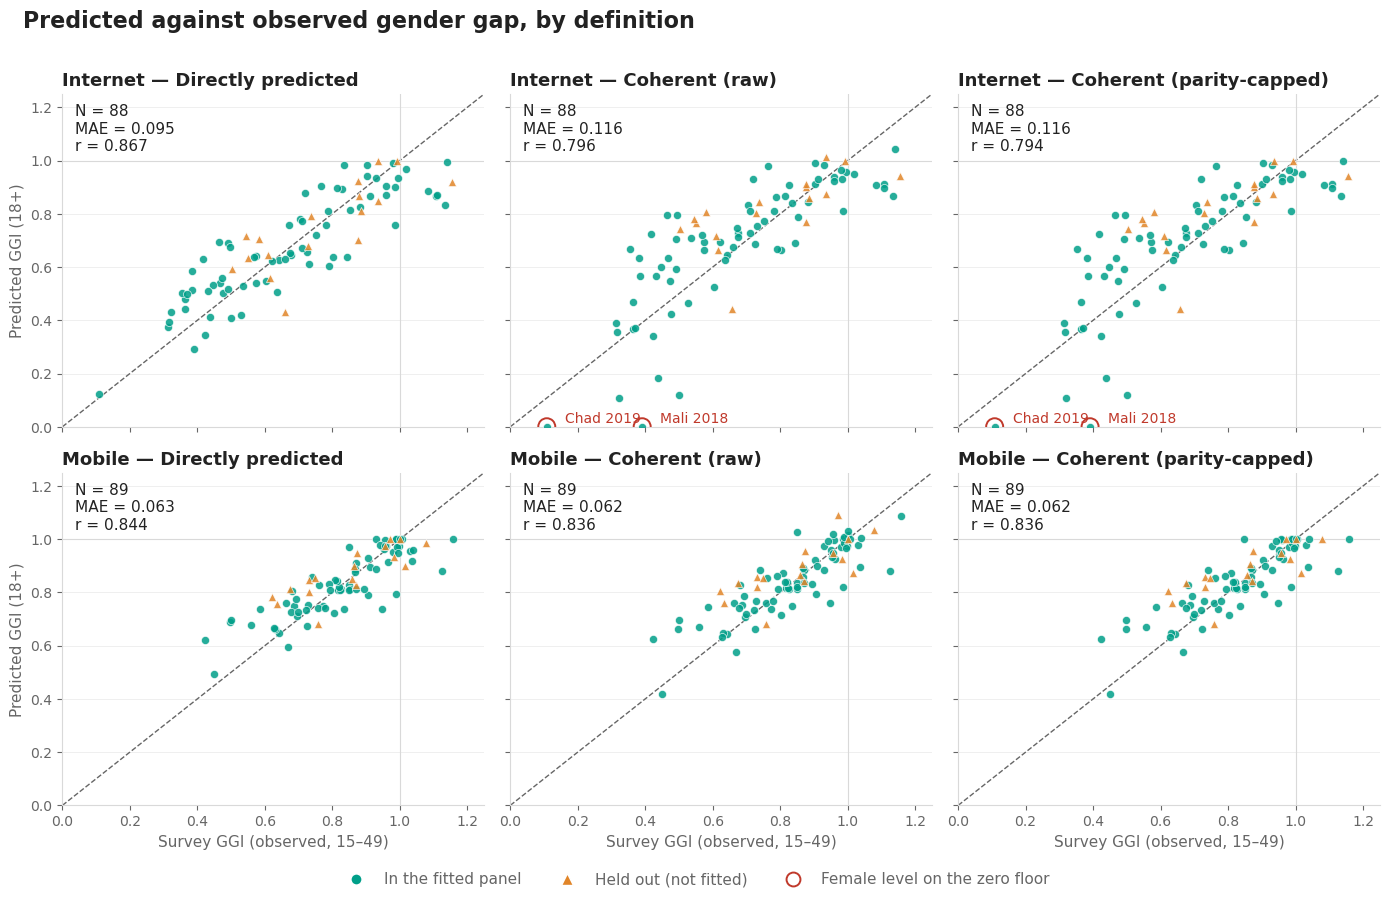

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=True, sharey=True)

for row, indicator in enumerate(params.COHERENT_GGI['indicators']):
    for col, definition in enumerate(['direct', 'coherent_raw', 'coherent_parity']):
        ax = axes[row, col]
        block = gt[(gt['indicator'] == indicator) & (gt['definition'] == definition)]
        st = gt_stats[(gt_stats['indicator'] == indicator)
                      & (gt_stats['definition'] == definition)
                      & (gt_stats['sample'] == 'all')].iloc[0]

        lim = (0.0, 1.25)
        ax.plot(lim, lim, ls='--', color=MUTED, linewidth=1, zorder=1)
        ax.axhline(1.0, color=GRID, linewidth=0.8, zorder=1)
        ax.axvline(1.0, color=GRID, linewidth=0.8, zorder=1)

        # in-sample first so the held-out points, which carry the argument, sit on top
        for flag in (True, False):
            key = 'in_training' if flag else 'held_out'
            pts = block[block['in_training'] == flag]
            ax.scatter(pts['observed'], pts['predicted'], s=34, alpha=0.85,
                       marker=SAMPLE_MARKER[key], color=SAMPLE_COLOUR[key],
                       edgecolor='white', linewidth=0.5, zorder=3 if flag else 4)

        # Two points carry an explanation the axes cannot: ring them, so the reader is not left
        # to guess why a prediction is exactly zero. They are labelled below.
        floored = block[block['zero_floor'] & (definition != 'direct')]
        ax.scatter(floored['observed'], floored['predicted'], s=150, facecolors='none',
                   edgecolor=ZERO_RING, linewidth=1.4, zorder=5)

        ax.text(0.03, 0.97, f"N = {int(st['n'])}\nMAE = {st['mae']:.3f}\nr = {st['pearson_r']:.3f}",
                transform=ax.transAxes, va='top', ha='left',
                fontsize=STYLE['tick_fs'], color=INK)

        tidy(ax, title=f'{indicator.capitalize()} — {DEF_LABEL[definition]}')
        ax.set_xlim(lim); ax.set_ylim(lim)
        if row == 1:
            ax.set_xlabel('Survey GGI (observed, 15–49)', fontsize=STYLE['tick_fs'], color=MUTED)
        if col == 0:
            ax.set_ylabel('Predicted GGI (18+)', fontsize=STYLE['tick_fs'], color=MUTED)

        # Label the points sitting on the x-axis, offset right so they do not obscure the
        # scatter. The YEAR matters as much as the country: Mali appears twice in this panel
        # (2018 on the floor, 2023 at 0.44), and without it the two read as one contradictory
        # point. Coloured to match the ring.
        for _, row_ in block.iterrows():
            if row_['predicted'] < 0.01:
                ax.annotate(f"{row_['country']} {int(row_['year'])}",
                            (row_['observed'], row_['predicted']),
                            xytext=(13, 1), textcoords='offset points', va='bottom',
                            fontsize=STYLE['tick_fs'] - 1, color=ZERO_RING)



handles = [plt.Line2D([], [], marker=SAMPLE_MARKER[k], linestyle='None', markersize=8,
                      markerfacecolor=SAMPLE_COLOUR[k], markeredgecolor='white',
                      label=SAMPLE_LABEL[k])
           for k in ('in_training', 'held_out')]
handles.append(plt.Line2D([], [], marker='o', linestyle='None', markersize=10,
                          markerfacecolor='none', markeredgecolor=ZERO_RING, markeredgewidth=1.4,
                          label='Female level on the zero floor'))
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.01))
fig.suptitle('Predicted against observed gender gap, by definition',
             fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=(0, 0.03, 1, 0.97))
if STYLE['save']:
    fig.savefig(FIGDIR / 'F1_groundtruth_scatter.png', dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()


### Accuracy, by definition and sample

Mean absolute error against the survey. Lower is better; the question is whether the coherent GGI,
which the project made primary in D16, tracks the observation at least as well as the direct
prediction it replaced.

The third series drops the rows where the predicted **female level sits exactly on the zero
floor** — there the coherent GGI is `0 / male = 0` by construction and reports the clip, not a gap
(D19). In this sample that is **Mali 2018 and Chad 2019**, internet only; no mobile row is
affected, which is why the mobile panel's three series coincide.

**That filter is not a fair-comparison device.** It is selected on the coherent measure's own
failure mode, which the direct prediction does not share, so "coherent beats direct once we drop
these" would be circular. It answers only: *how does the coherent GGI do where it is defined at
all* (D34).


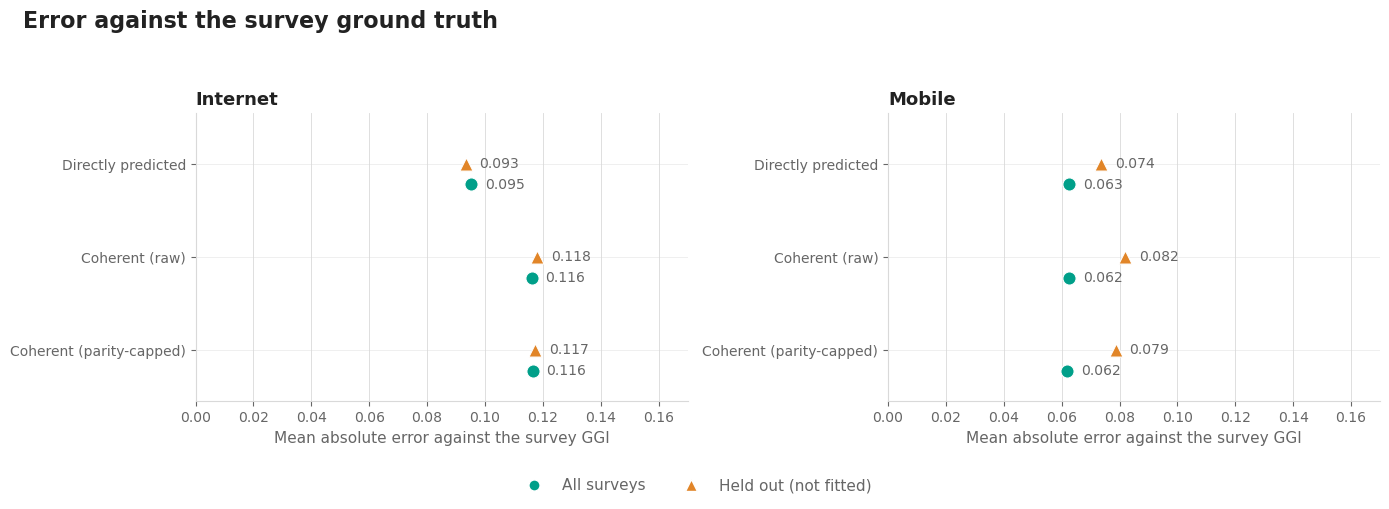

,indicator,definition,sample,n_dropped_zero_floor,n,bias,mae,rmse,r2,within_0.05,within_0.10,pearson_r,spearman_r
0,internet,coherent_parity,all,0,88,0.0210,0.1165,0.1498,0.5911,28.4091,52.2727,0.7938,0.8512
1,internet,coherent_parity,in_training,0,71,0.0153,0.1163,0.1511,0.6076,28.1690,53.5211,0.8036,0.8503
2,internet,coherent_parity,held_out,0,17,0.0446,0.1174,0.1439,0.3816,29.4118,47.0588,0.6659,0.8056
3,internet,coherent_parity,held_out_new_country,0,4,0.0529,0.0529,0.0641,0.8087,50.0000,75.0000,0.9886,0.9487
4,internet,coherent_raw,all,0,88,0.0216,0.1161,0.1494,0.5929,28.4091,53.4091,0.7956,0.8513
5,internet,coherent_raw,in_training,0,71,0.0159,0.1157,0.1507,0.6101,28.1690,54.9296,0.8057,0.8503
6,internet,coherent_raw,held_out,0,17,0.0454,0.1182,0.1442,0.3786,29.4118,47.0588,0.6656,0.8039
7,internet,coherent_raw,held_out_new_country,0,4,0.0560,0.0560,0.0674,0.7884,50.0000,75.0000,0.9818,0.8000
8,internet,direct,all,0,88,-0.0029,0.0951,0.1174,0.7489,29.5455,65.9091,0.8668,0.8661
9,internet,direct,in_training,0,71,-0.0004,0.0956,0.1179,0.7614,29.5775,64.7887,0.8748,0.8651


In [11]:
SAMPLES = ['all', 'held_out'] + (['all_excl_zero'] if ZERO_CTRL else [])
OFFSET = {'all': 0.22, 'held_out': 0.0, 'all_excl_zero': -0.22}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), sharex=True)

ORDER = ['direct', 'coherent_raw', 'coherent_parity']
for ax, indicator in zip(axes, params.COHERENT_GGI['indicators']):
    block = gt_stats[gt_stats['indicator'] == indicator]
    ypos = np.arange(len(ORDER))

    for key in SAMPLES:
        vals = [block[(block['definition'] == d) & (block['sample'] == key)]['mae'].squeeze()
                for d in ORDER]
        ax.scatter(vals, ypos + OFFSET[key], s=90, marker=SAMPLE_MARKER[key],
                   color=SAMPLE_COLOUR[key], edgecolor='white', linewidth=0.8, zorder=3)
        # Labels sit to the RIGHT of their own marker, not above it: the three samples differ by
        # ~0.003, so stacked labels land on the neighbouring series' marker.
        for v, y in zip(vals, ypos + OFFSET[key]):
            ax.annotate(f'{v:.3f}', (v, y), textcoords='offset points', xytext=(10, 0),
                        ha='left', va='center', fontsize=STYLE['tick_fs'] - 1, color=MUTED)

    ax.set_yticks(ypos)
    ax.set_yticklabels([DEF_LABEL[d] for d in ORDER])
    ax.set_ylim(len(ORDER) - 0.45, -0.55)
    ax.grid(axis='x', color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    tidy(ax, title=indicator.capitalize(),
         xlabel='Mean absolute error against the survey GGI')
    ax.set_xlim(0, max(0.17, block['mae'].max() * 1.5))

handles2 = [plt.Line2D([], [], marker=SAMPLE_MARKER[k], linestyle='None', markersize=8,
                       markerfacecolor=SAMPLE_COLOUR[k], markeredgecolor='white',
                       label=SAMPLE_LABEL[k])
            for k in SAMPLES]
fig.legend(handles=handles2, loc='lower center', ncol=len(SAMPLES), frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.10))
fig.suptitle('Error against the survey ground truth', fontsize=STYLE['title_fs'],
             color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=(0, 0, 1, 0.92))
if STYLE['save']:
    fig.savefig(FIGDIR / 'F2_groundtruth_mae.png', dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()

gt_stats.round(4)


### Where the error comes from

The GGI is a ratio of two predicted levels, so any error in it is inherited. Scoring the levels
separately says whether the women's series, the men's series, or the ratio construction is
responsible.


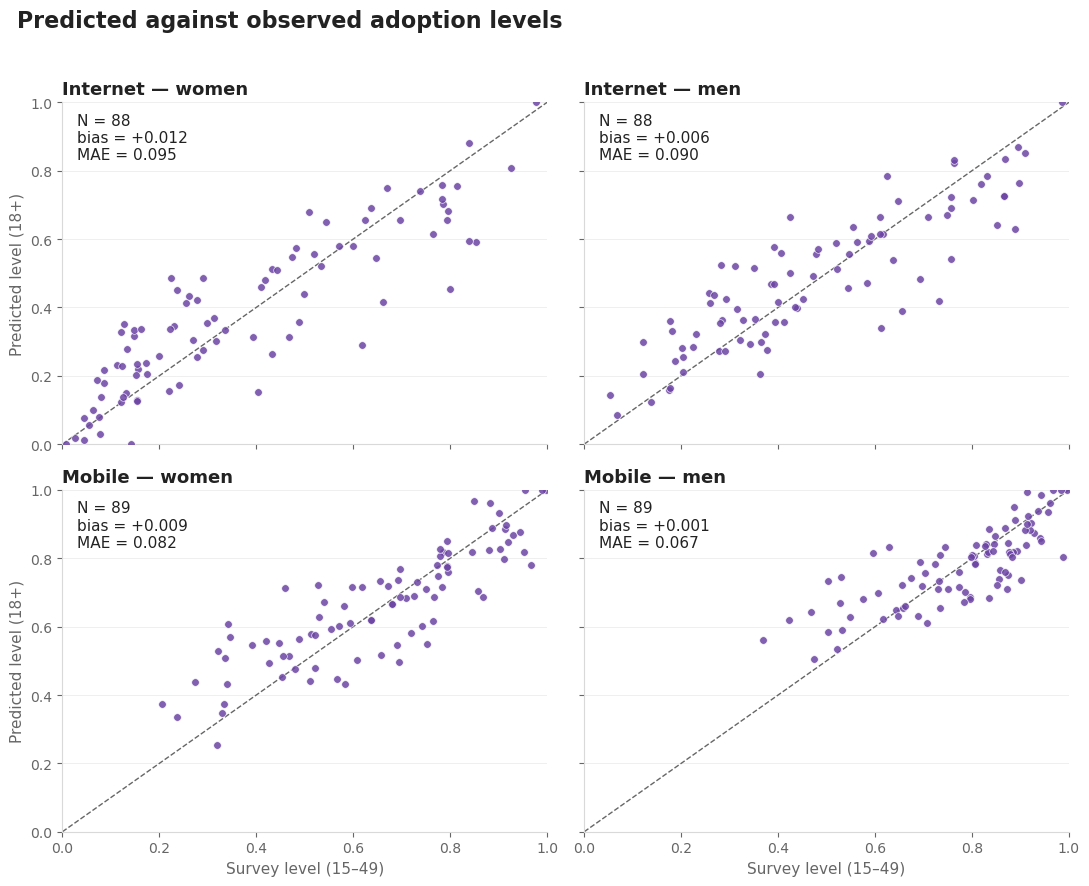

,indicator,sex,sample,n,bias,mae,rmse,r2,within_0.05,within_0.10,pearson_r,spearman_r
0,internet,men,all,88,0.0060,0.0903,0.1166,0.7561,34.0909,69.3182,0.8705,0.8615
1,internet,men,in_training,71,0.0033,0.0838,0.1104,0.7758,36.6197,74.6479,0.8822,0.8801
2,internet,men,held_out,17,0.0172,0.1172,0.1396,0.6317,23.5294,47.0588,0.7983,0.7034
3,internet,men,held_out_new_country,4,0.0108,0.0229,0.0240,0.9914,100.0000,100.0000,0.9979,1.0000
4,internet,women,all,88,0.0115,0.0949,0.1232,0.7810,34.0909,60.2273,0.8850,0.8844
5,internet,women,in_training,71,0.0082,0.0840,0.1098,0.8167,36.6197,64.7887,0.9051,0.9028
6,internet,women,held_out,17,0.0256,0.1404,0.1680,0.6144,23.5294,41.1765,0.7899,0.7892
7,internet,women,held_out_new_country,4,0.0406,0.0406,0.0426,0.9799,75.0000,100.0000,0.9997,1.0000
8,mobile,men,all,89,0.0011,0.0668,0.0894,0.6278,44.9438,77.5281,0.7928,0.8083
9,mobile,men,in_training,72,-0.0013,0.0684,0.0905,0.6347,43.0556,79.1667,0.7973,0.8095


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9), sharex=True, sharey=True)

for row, indicator in enumerate(params.COHERENT_GGI['indicators']):
    for col, sex in enumerate(['women', 'men']):
        ax = axes[row, col]
        block = gt_levels[(gt_levels['indicator'] == indicator) & (gt_levels['sex'] == sex)]
        st = gt_level_stats[(gt_level_stats['indicator'] == indicator)
                            & (gt_level_stats['sex'] == sex)].iloc[0]

        lim = (0.0, 1.0)
        ax.plot(lim, lim, ls='--', color=MUTED, linewidth=1, zorder=1)
        ax.scatter(block['observed'], block['predicted'], s=30, alpha=0.85,
                   color=PALETTE[2], edgecolor='white', linewidth=0.5, zorder=3)

        ax.text(0.03, 0.97,
                f"N = {int(st['n'])}\nbias = {st['bias']:+.3f}\nMAE = {st['mae']:.3f}",
                transform=ax.transAxes, va='top', ha='left',
                fontsize=STYLE['tick_fs'], color=INK)

        tidy(ax, title=f"{indicator.capitalize()} — {sex}")
        ax.set_xlim(lim); ax.set_ylim(lim)
        if row == 1:
            ax.set_xlabel('Survey level (15–49)', fontsize=STYLE['tick_fs'], color=MUTED)
        if col == 0:
            ax.set_ylabel('Predicted level (18+)', fontsize=STYLE['tick_fs'], color=MUTED)

fig.suptitle('Predicted against observed adoption levels', fontsize=STYLE['title_fs'],
             color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=(0, 0, 1, 0.96))
if STYLE['save']:
    fig.savefig(FIGDIR / 'F3_groundtruth_levels.png', dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()

gt_level_stats.round(4)


In [13]:
# the surveys the models never saw, worst-fitting first — the rows worth reading individually.
# Note both zero-floor rows are *in* the fitted panel, so none of them appear here; that is why
# the held-out numbers are identical with and without the filter.
held = gt[(~gt['in_training']) & (gt['definition'] == 'coherent_parity')]
display((held[['indicator', 'gid_0', 'country', 'year', 'survey_type',
               'observed', 'predicted', 'error']]
         .assign(abs_error=lambda d: d['error'].abs())
         .sort_values(['indicator', 'abs_error'], ascending=[True, False])
         .drop(columns='abs_error').round(4).reset_index(drop=True)))

# every row the zero-floor filter removes, under each definition
gt[gt['zero_floor']][['indicator', 'definition', 'gid_0', 'country', 'year', 'survey_type',
                      'in_training', 'observed', 'predicted']].round(4).reset_index(drop=True)


,indicator,gid_0,country,year,survey_type,observed,predicted,error
0,internet,ETH,Ethiopia,2024,dhs8,0.5033,0.7426,0.2393
1,internet,NGA,Nigeria,2024,dhs8,0.5453,0.7791,0.2338
2,internet,AGO,Angola,2023,dhs8,0.5813,0.8062,0.2249
3,internet,MWI,Malawi,2024,dhs8,0.5497,0.7650,0.2153
4,internet,MLI,Mali,2023,dhs8,0.6582,0.4440,-0.2142
5,internet,LSO,Lesotho,2022,dhs8,1.1540,0.9412,-0.2128
6,internet,ZMB,Zambia,2024,dhs8,0.7380,0.8446,0.1067
7,internet,SEN,Senegal,2023,continuous dhs8,0.8756,0.7692,-0.1064
8,internet,MOZ,Mozambique,2022,dhs8,0.6099,0.7157,0.1058
9,internet,RWA,Rwanda,2025,dhs8,0.7282,0.8023,0.0741


,indicator,definition,gid_0,country,year,survey_type,in_training,observed,predicted
0,internet,coherent_parity,MLI,Mali,2018,dhs7,True,0.3909,0.0000
1,internet,coherent_parity,TCD,Chad,2019,mics6,True,0.1081,0.0000
2,internet,coherent_raw,MLI,Mali,2018,dhs7,True,0.3909,0.0000
3,internet,coherent_raw,TCD,Chad,2019,mics6,True,0.1081,0.0000
4,internet,direct,MLI,Mali,2018,dhs7,True,0.3909,0.2920
5,internet,direct,TCD,Chad,2019,mics6,True,0.1081,0.1235


## G. The three definitions on the surveys the models never saw

Section F scores all 88–89 country-years, most of which are *in* the fitted panel. This section
keeps only the **17 surveys added in the 2026-08 refresh**, which no model saw. It is the same
question as F — which definition tracks the observation — asked where the answer cannot be fit.

The outcomes behind these ratios, country by country, are in
`08_01_unseen_survey_validation.ipynb`; here the subject is only the choice between definitions.

Both caveats from F still apply: surveys are 15–49 against 18+ predictions, and n = 17 is small
enough that a difference of a few thousandths means nothing.

In [14]:
held = gt[~gt['in_training']].copy()
print(f"{held['gid_0'].nunique()} countries | {len(held)//len(DEF_LABEL)} surveys per indicator")

# head to head: for each survey, which definition landed closest
wide = held.pivot_table(index=['indicator', 'gid_0', 'country', 'year', 'survey_type', 'observed'],
                        columns='definition', values='error').reset_index()
for d in DEF_LABEL:
    wide[f'abs_{d}'] = wide[d].abs()
wide['closest'] = wide[[f'abs_{d}' for d in DEF_LABEL]].idxmin(axis=1).str.removeprefix('abs_')

wins = (wide.groupby(['indicator', 'closest']).size()
        .unstack(fill_value=0).reindex(columns=list(DEF_LABEL), fill_value=0))
print('\nsurveys where each definition came closest:')
display(wins)

gt_stats[gt_stats['sample'] == 'held_out'].round(4)

17 countries | 34 surveys per indicator

surveys where each definition came closest:


closest,coherent_parity,coherent_raw,direct
indicator,,,
internet,9,0,8
mobile,5,1,11


,indicator,definition,sample,n_dropped_zero_floor,n,bias,mae,rmse,r2,within_0.05,within_0.10,pearson_r,spearman_r
2,internet,coherent_parity,held_out,0,17,0.0446,0.1174,0.1439,0.3816,29.4118,47.0588,0.6659,0.8056
6,internet,coherent_raw,held_out,0,17,0.0454,0.1182,0.1442,0.3786,29.4118,47.0588,0.6656,0.8039
10,internet,direct,held_out,0,17,-0.0135,0.0933,0.1153,0.6025,29.4118,70.5882,0.7825,0.7885
14,mobile,coherent_parity,held_out,0,17,0.0330,0.0786,0.0954,0.5208,35.2941,64.7059,0.7762,0.8329
18,mobile,coherent_raw,held_out,0,17,0.0404,0.0819,0.0982,0.4926,35.2941,58.8235,0.7622,0.8260
22,mobile,direct,held_out,0,17,0.0282,0.0736,0.0871,0.6006,41.1765,64.7059,0.8187,0.8331


### Is the coherent GGI closer or further than the direct prediction, survey by survey?

Each line runs from the absolute error under the direct prediction to the error under the coherent
(parity-capped) GGI. A line sloping **down to the right** means the coherent definition was closer
on that survey. Aggregates hide that this is a mix, not a uniform shift.

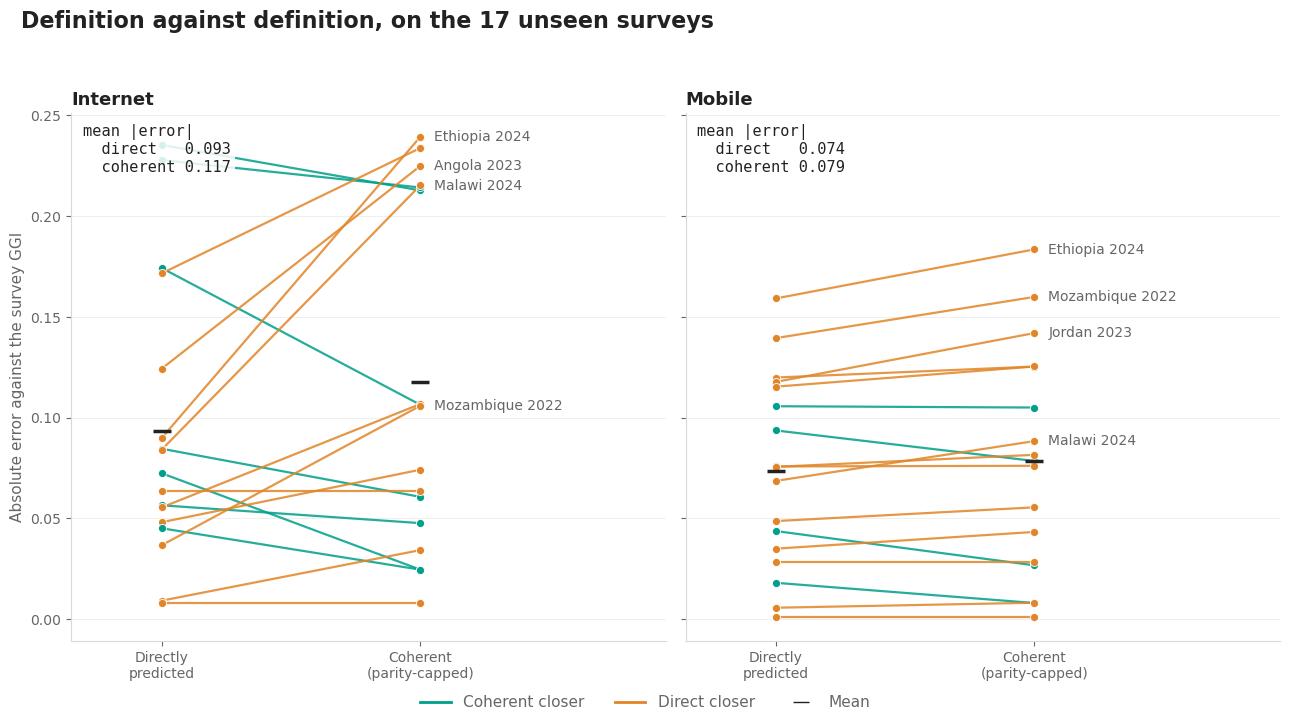

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

N_LABEL = 4          # only the biggest movers get named; 17 labels is unreadable
LABEL_GAP = 0.012    # minimum vertical spacing between labels, in data units

for ax, indicator in zip(axes, params.COHERENT_GGI['indicators']):
    block = (wide[wide['indicator'] == indicator]
             .assign(shift=lambda d: (d['abs_coherent_parity'] - d['abs_direct']).abs())
             .sort_values('abs_direct', ascending=False).reset_index(drop=True))

    for _, r in block.iterrows():
        better = r['abs_coherent_parity'] < r['abs_direct']
        colour = PALETTE[0] if better else PALETTE[1]
        ax.plot([0, 1], [r['abs_direct'], r['abs_coherent_parity']],
                color=colour, linewidth=1.6, alpha=0.85, zorder=2)
        ax.scatter([0, 1], [r['abs_direct'], r['abs_coherent_parity']], s=34,
                   color=colour, edgecolor='white', linewidth=0.6, zorder=3)

    # Labels are placed at their own y, then pushed apart just enough not to overlap: several
    # surveys land within a thousandth of each other and would otherwise print on top.
    named = block.nlargest(N_LABEL, 'shift').sort_values('abs_coherent_parity')
    last_y = -np.inf
    for _, r in named.iterrows():
        y = max(r['abs_coherent_parity'], last_y + LABEL_GAP)
        ax.annotate(f"{r['country']} {int(r['year'])}", (1, r['abs_coherent_parity']),
                    xytext=(10, 0), textcoords='offset points', va='center',
                    xycoords='data', annotation_clip=False,
                    fontsize=STYLE['tick_fs'] - 1, color=MUTED)
        last_y = y

    means = {k: block[k].mean() for k in ('abs_direct', 'abs_coherent_parity')}
    for x, key in ((0, 'abs_direct'), (1, 'abs_coherent_parity')):
        ax.scatter([x], [means[key]], s=170, marker='_', color=INK, linewidth=2.5, zorder=4)

    # the two means as one corner note, so they never land in the label column
    ax.text(0.02, 0.98,
            f"mean |error|\n  direct   {means['abs_direct']:.3f}\n"
            f"  coherent {means['abs_coherent_parity']:.3f}",
            transform=ax.transAxes, va='top', ha='left', family='monospace',
            fontsize=STYLE['tick_fs'], color=INK,
            bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=3))

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Directly\npredicted', 'Coherent\n(parity-capped)'])
    ax.set_xlim(-0.35, 1.95)
    ax.grid(axis='y', color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    tidy(ax, title=indicator.capitalize())

axes[0].set_ylabel('Absolute error against the survey GGI',
                   fontsize=STYLE['tick_fs'], color=MUTED)
handles = [plt.Line2D([], [], color=PALETTE[0], linewidth=2, label='Coherent closer'),
           plt.Line2D([], [], color=PALETTE[1], linewidth=2, label='Direct closer'),
           plt.Line2D([], [], color=INK, linewidth=2.5, marker='_', linestyle='None',
                      markersize=12, label='Mean')]
fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False,
           fontsize=STYLE['tick_fs'], labelcolor=MUTED, bbox_to_anchor=(0.5, -0.04))
fig.suptitle('Definition against definition, on the 17 unseen surveys',
             fontsize=STYLE['title_fs'], color=INK, fontweight='bold', x=0.02, ha='left')
fig.tight_layout(rect=(0, 0, 1, 0.94))
if STYLE['save']:
    fig.savefig(FIGDIR / 'G_unseen_definition_duel.png', dpi=STYLE['dpi'], bbox_inches='tight')
plt.show()


### Survey by survey

Signed error under each definition; positive means the model sits above the survey.

In [16]:
(wide[['indicator', 'gid_0', 'country', 'year', 'survey_type', 'observed']
      + list(DEF_LABEL) + ['closest']]
 .sort_values(['indicator', 'year', 'gid_0'])
 .round(4).reset_index(drop=True))

definition,indicator,gid_0,country,year,survey_type,observed,coherent_parity,coherent_raw,direct,closest
0,internet,LSO,Lesotho,2022,dhs8,1.1540,-0.2128,-0.2128,-0.2353,coherent_parity
1,internet,MOZ,Mozambique,2022,dhs8,0.6099,0.1058,0.1058,0.0366,direct
2,internet,AGO,Angola,2023,dhs8,0.5813,0.2249,0.2249,0.1243,direct
3,internet,COD,DR Congo,2023,dhs8,0.6163,0.0476,0.0476,-0.0564,coherent_parity
4,internet,JOR,Jordan,2023,dhs8,0.8846,-0.0245,-0.0245,-0.0723,coherent_parity
5,internet,LAO,Laos,2023,mics6,0.9342,-0.0606,-0.0606,-0.0845,coherent_parity
6,internet,MLI,Mali,2023,dhs8,0.6582,-0.2142,-0.2142,-0.2278,coherent_parity
7,internet,NRU,Nauru,2023,mics6,0.9366,0.0634,0.0759,0.0634,coherent_parity
8,internet,QAT,Qatar,2023,mics6,0.9919,0.0081,0.0081,0.0081,coherent_parity
9,internet,SEN,Senegal,2023,continuous dhs8,0.8756,-0.1064,-0.1064,-0.1742,coherent_parity


## Notes

- Figures write to `outputs/fig/ggi_comparison/`; the figure-ready CSVs live in `outputs/tables/`
  under the `ggi_comparison_` prefix, one per panel.
- The common sample drops any country not complete under all three definitions and both indicators.
  Only Niger is affected — its 2015 internet levels are both zero, so no ratio is defined (D19).
- Panel A plots the **raw** coherent GGI so values above parity remain visible. Panels B and D use
  the parity-capped variant, which is the primary measure (D16); panel D shows the raw variant
  alongside it for comparison.